# `SympyLineshape` aplicado ao Dalitz de `B+ -> pi+ pi+ pi-`

Este exemplo coloca uma expressão SymPy dentro de um `DecayModel` completo.
Usamos o polo simples
\[
R(m) = \frac{1}{m-m_0-i\Gamma_0/2},
\]
como um exemplo de line shape definida pelo usuário para um par `pi+ pi-`.

O restante da construção permanece o mesmo: `Resonance` adiciona fatores de
barreira e angulares e, como há dois `pi+` idênticos, soma automaticamente as
duas permutações do par `pi+ pi-`. A expressão simbólica fornece apenas a
parte unidimensional dependente da massa do par.

O notebook gera uma amostra de espaço de fase, prepara a normalização no plano
de Dalitz, mostra a intensidade e verifica o gradiente dos parâmetros dinâmicos.
Ele requer `python -m pip install -e ".[sympy]"`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import jax
import jax.numpy as jnp

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, NonResonant, Parameter,
    Pole, RealImag, Resonance, ResonanceContext, SympyLineshape, Zemach_P,
    enable_x64,
)

enable_x64()
print(f"SymPy {sp.__version__}; JAX {jax.__version__}; dispositivo: {jax.devices()[0]}")

SymPy 1.14.0; JAX 0.11.1; dispositivo: cuda:0


## 1. Expressão e parâmetros do polo

Os símbolos `m0` e `gamma` serão ligados a parâmetros dinâmicos declarados
explicitamente em `Resonance`. Assim, os mesmos valores controlam o contexto da
line shape, a posição usada pela integração adaptativa e os fatores de barreira.
A expressão é compilada uma única vez para JAX.

In [2]:
m, m0, gamma = sp.symbols("m m0 gamma", real=True)
pole_expression = 1 / (m - m0 - sp.I * gamma / 2)

rho_mass = Parameter.dynamics(
    "rho0.mass", 0.775, owner="rho0", bounds=(0.70, 0.85), step=0.001,
)
rho_width = Parameter.dynamics(
    "rho0.width", 0.150, owner="rho0", bounds=(0.08, 0.25), step=0.001,
)

rho0_sympy = SympyLineshape(
    pole_expression,
    mass_symbol=m,
    context_symbols={m0: "pole_mass", gamma: "pole_width"},
)
context = ResonanceContext(
    parent_mass=5.27934,
    daughter_masses=(0.13957039, 0.13957039),
    bachelor_mass=0.13957039,
    spin=1,
    pole_mass=0.775,
    pole_width=0.150,
)
mass_grid = jnp.linspace(0.30, 5.14, 700)
symbolic_values = rho0_sympy(mass_grid, context)
reference_values = Pole()(mass_grid, context)
np.testing.assert_allclose(symbolic_values, reference_values, rtol=1e-12, atol=1e-12)
print("A expressão SymPy reproduz Pole(): diferença máxima =",
      float(jnp.max(jnp.abs(symbolic_values - reference_values))))

A expressão SymPy reproduz Pole(): diferença máxima = 4.440892098500626e-15


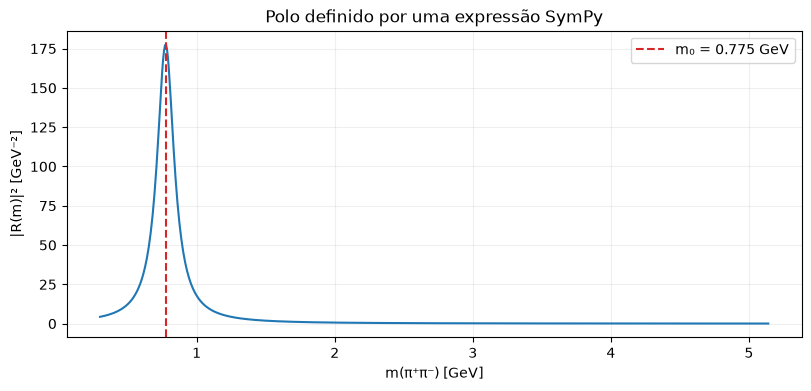

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
ax.plot(mass_grid, np.asarray(jnp.abs(symbolic_values) ** 2))
ax.axvline(0.775, color="tab:red", ls="--", label="m₀ = 0.775 GeV")
ax.set(xlabel="m(π⁺π⁻) [GeV]", ylabel="|R(m)|² [GeV⁻²]",
       title="Polo definido por uma expressão SymPy")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

## 2. Construir o modelo de Dalitz

No canal `B+ -> pi+ pi+ pi-`, o par `(0, 2)` é `pi+ pi-` e a partícula
bachelor é o segundo `pi+`. O `DecayModel` reconhece as partículas idênticas e
simetriza a amplitude automaticamente, portanto a mesma line shape aparece nas
bandas correspondentes a `(0, 2)` e `(1, 2)`. Usamos `spin=1` e selecionamos
explicitamente `Zemach_P()`, para que o fator angular e os fatores de forma
sejam não triviais. Um modelo de referência com `Pole()` nativo é comparado
ponto a ponto para verificar essa composição.

Incluímos uma pequena contribuição não ressonante apenas para tornar explícita
a soma coerente; ela não é necessária para usar a line shape.

In [4]:
model = DecayModel(
    DecayChannel("B+", ("pi+", "pi+", "pi-")),
    [
        Resonance(
            "rho0", pair=(0, 2), coefficient=RealImag(1.0, 0.0),
            lineshape=rho0_sympy, mass=rho_mass, width=rho_width, spin=1,
            angular=Zemach_P(),
        ),
        NonResonant(RealImag(0.08, 0.0)),
    ],
    normalization_method="square-dalitz",
    normalization_resolution=50,
)
print("Parâmetros coletados:", [p.name for p in model.parameters])
assert {p.name for p in model.parameters} == {"rho0.mass", "rho0.width"}

# Referência nativa: só a implementação da line shape muda.
reference_model = DecayModel(
    DecayChannel("B+", ("pi+", "pi+", "pi-")),
    [
        Resonance(
            "rho0", pair=(0, 2), coefficient=RealImag(1.0, 0.0),
            lineshape=Pole(), mass=rho_mass, width=rho_width, spin=1,
            angular=Zemach_P(),
        ),
        NonResonant(RealImag(0.08, 0.0)),
    ],
    normalization_method="square-dalitz",
    normalization_resolution=50,
)


Parâmetros coletados: ['rho0.mass', 'rho0.width']


## 3. Intensidade no plano de Dalitz

A amostra abaixo é apenas espaço de fase uniforme em coordenadas de geração;
ela serve para visualizar o suporte físico. A intensidade vem do modelo completo.
Usamos `s13 = m²(pi⁺pi⁻)` e `s23 = m²(pi⁺pi⁻)` para os dois pareamentos
simetrizados. As duas faixas são uma consequência da simetrização, não duas
line shapes declaradas separadamente.

In [5]:
normalization = model.normalization_sample
data = model.generate_phase_space(7000, seed=20260915)
session = FitSession(model, data)
cache = session.signal_cache
reference_cache = reference_model.prepare_cache(data, normalization)
fit_objective = session.objective
truth = {"rho0.mass": 0.775, "rho0.width": 0.150}
intensity, integral = cache.evaluate(truth)
intensity = np.asarray(intensity)
reference_intensity, reference_integral = reference_cache.evaluate(truth)
np.testing.assert_allclose(intensity, reference_intensity, rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(integral, reference_integral, rtol=1e-12, atol=1e-12)
print("Verificação angular: SympyLineshape e Pole() nativo coincidem com spin=1 e Zemach_P().")
assert np.all(np.isfinite(intensity)) and np.all(intensity > 0)
assert np.isfinite(float(integral)) and float(integral) > 0
print(f"Pontos de normalização: {normalization.size:,}")
print(f"Integral média da intensidade: {float(integral):.6g}")
print(f"Intensidade: mínimo={intensity.min():.3g}, máximo={intensity.max():.3g}")

Verificação angular: SympyLineshape e Pole() nativo coincidem com spin=1 e Zemach_P().
Pontos de normalização: 2,500
Integral média da intensidade: 1.0064
Intensidade: mínimo=1.73e-08, máximo=0.216


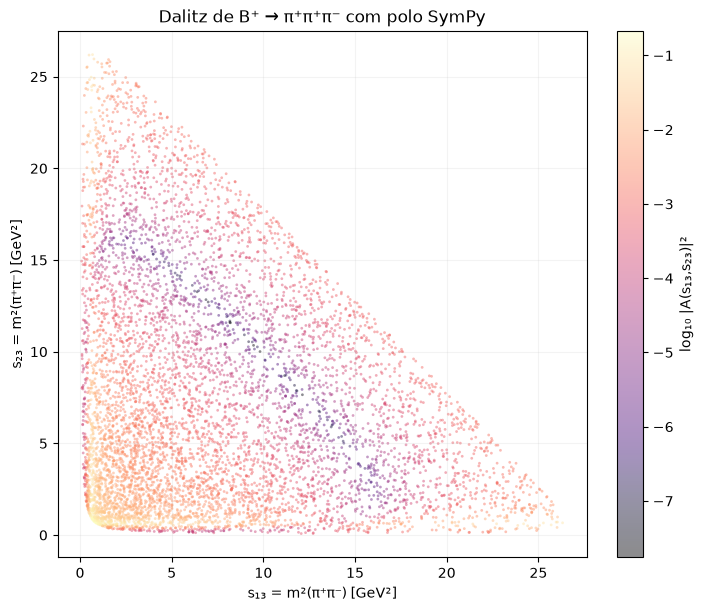

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 6), constrained_layout=True)
scatter = ax.scatter(
    np.asarray(data.s13), np.asarray(data.s23),
    c=np.log10(intensity), s=4, alpha=0.45, linewidths=0,
    cmap="magma",
)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("log₁₀ |A(s₁₃,s₂₃)|²")
ax.set(
    xlabel="s₁₃ = m²(π⁺π⁻) [GeV²]",
    ylabel="s₂₃ = m²(π⁺π⁻) [GeV²]",
    title="Dalitz de B⁺ → π⁺π⁺π⁻ com polo SymPy",
)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.15)
plt.show()

## 4. Gradientes através da normalização

Os parâmetros `rho0.mass` e `rho0.width` são `DYNAMICS`; o cache recalcula o
componente e a matriz de normalização quando eles variam. O gradiente abaixo é
do objetivo normalizado completo, usando os mesmos pontos de suporte para manter
o exemplo determinístico. A comparação com diferenças finitas deve ser pequena.

In [7]:
def objective(values):
    return fit_objective(values)

def nll_vector(vector):
    return objective({"rho0.mass": vector[0], "rho0.width": vector[1]})

point = jnp.array([0.781, 0.142])
gradient = np.asarray(jax.jit(jax.grad(nll_vector))(point))
finite_difference = []
for index in range(2):
    step = 1e-6
    delta = jnp.zeros(2).at[index].set(step)
    finite_difference.append(float((nll_vector(point + delta) - nll_vector(point - delta)) / (2 * step)))
finite_difference = np.asarray(finite_difference)
print("JAX:", gradient)
print("Diferenças finitas:", finite_difference)
np.testing.assert_allclose(gradient, finite_difference, rtol=2e-5, atol=2e-6)

JAX: [  9618.29324424 -33374.44668315]
Diferenças finitas: [  9618.29324297 -33374.44668796]


## 5. Ajuste opcional e observações

Para um ajuste real, use eventos independentes e verifique a convergência da
normalização em várias resoluções. Aqui mostramos somente que o caminho do
minimizador recebe os parâmetros declarados pelo usuário.

In [8]:
result = session.fit(
    start_values={"rho0.mass": 0.760, "rho0.width": 0.165},
    strategy=1, hesse=False, tolerance=1e-7,
)
print("Ajuste válido:", result.valid)
session.print_result(result)
print("Valores ajustados:", session.result_values(result))
assert result.valid

Ajuste válido: True
valid=True  NLL=47637.302566
parameter                           value            error
rho0.mass                             0.7      7.73818e-05
rho0.width                           0.25      3.75954e-05
Valores ajustados: {'rho0.mass': 0.7, 'rho0.width': 0.25}


A forma tradicional continua disponível no mesmo modelo:

```python
Resonance("rho0", (0, 2), RealImag(1, 0), lineshape=Pole(), ...)
```

Trocar `Pole()` por `SympyLineshape(...)` é a única mudança. Expressões SymPy
com estruturas estreitas adicionais não são detectadas automaticamente pela
refinação da grade; nesse caso, aumente a resolução e faça um estudo de
convergência explícito.